In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_gaussian_quantiles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 1. Create a synthetic dataset
X, y = make_gaussian_quantiles(n_samples=500, n_features=2,
                               n_classes=2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Initialize the Weak Learner (Decision Stump)
base_estimator = DecisionTreeClassifier(max_depth=1)

# 3. Initialize AdaBoost
# n_estimators: Number of stumps to train
# learning_rate: Shrinks the contribution of each classifier
ada = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# 4. Fit and Predict
ada.fit(X_train, y_train)
y_pred = ada.predict(X_test)

print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred):.4f}")

AdaBoost Accuracy: 0.9400


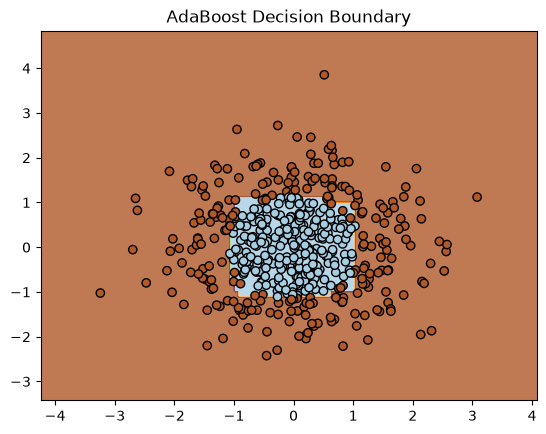

In [11]:
def plot_decision_boundary(model, X, y):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    plt.title("AdaBoost Decision Boundary")
    plt.show()
plot_decision_boundary(ada, X, y)